# Stack Overflow Developer Survey 2025
## Notebook 1 — Data Pipeline Setup & Leakage Audit

**Purpose:** Load `df_model_cleaned`, perform a full leakage audit, execute the 80/20 stratified split, and save split artefacts for consumption by Notebooks 2 and 3.

**Critical constraint:** The 80/20 split is performed ONCE here. Neither the regression pipelines nor the classification pipelines touch raw data — they load `X_train`, `X_test`, `y_reg_train`, `y_clf_train` etc. from the saved parquet files produced at the end of this notebook.

**Architecture:**
```
df_model_cleaned
│
├── Leakage Audit (column-level, target separation, scaling check)
│
├── 80/20 Stratified Split (stratify on UsesAI × ExperienceTier bucket)
│     ├── X_train  / y_reg_train  / y_clf_train   → /data/train/
│     └── X_test   / y_reg_test   / y_clf_test    → /data/test/  [LOCKED]
│
└── Split integrity checks (shape, class balance, WorkExp distribution)
```

## CONFIGURATION

In [4]:
class Config:
    """Central configuration for all three notebooks."""

    # ── Paths ──────────────────────────────────────────────────────────────
    # Update INPUT_PATH to point to your df_model_cleaned CSV/parquet
    INPUT_PATH   = r'C:\Users\ingex\OneDrive\Documents\Git Projects\Stack_Overflow_Survey\df_model_cleaned.csv'   # ← change if needed
    OUTPUT_DIR   = './data/'
    RESULTS_DIR  = './results/'

    # ── Split ──────────────────────────────────────────────────────────────
    TEST_SIZE    = 0.20
    RANDOM_STATE = 42

    # ── Target columns ─────────────────────────────────────────────────────
    TARGET_REG   = 'log_salary'             # regression target
    TARGET_CLF   = 'UsesAI'                 # classification target
    DROP_ALWAYS  = ['log_salary',           # never a feature
                    'ConvertedCompYearly']  # raw salary — never a feature

    # ── Feature sets ───────────────────────────────────────────────────────
    # Regression: UsesAI IS a feature (testing its marginal effect on salary)
    # Classification: UsesAI is the TARGET — drop from X
    CONTINUOUS_COLS = ['WorkExp']           # only col needing scaling

config = Config()
print('Config loaded.')

Config loaded.


## IMPORTS

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = config.RANDOM_STATE
np.random.seed(SEED)

os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Output  : {os.path.abspath(config.OUTPUT_DIR)}')

pandas  : 2.3.3
numpy   : 2.4.1
Output  : c:\Users\ingex\OneDrive\Documents\Git Projects\Stack_Overflow_Survey\notebooks\data


## LOAD DATA

In [6]:
df = pd.read_csv(config.INPUT_PATH)

print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'\nDtypes summary :')
print(df.dtypes.value_counts())
print(f'\nNull counts    :')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape          : (18014, 105)
Columns        : ['WorkExp', 'UsesAI', 'log_salary', 'ConvertedCompYearly', 'Region_Eastern Europe', 'Region_Latin America', 'Region_Middle East & North Africa', 'Region_North America', 'Region_Oceania', 'Region_Other', 'Region_South Asia', 'Region_Southeast Asia', 'Region_Sub-Saharan Africa', 'Region_Western Europe', 'DevType_Academic researcher', 'DevType_Applied scientist', 'DevType_Architect, software or solutions', 'DevType_Cloud infrastructure engineer', 'DevType_Cybersecurity or InfoSec professional', 'DevType_Data engineer', 'DevType_Data or business analyst', 'DevType_Data scientist', 'DevType_Database administrator or engineer', 'DevType_DevOps engineer or professional', 'DevType_Developer, AI apps or physical AI', 'DevType_Developer, QA or test', 'DevType_Developer, back-end', 'DevType_Developer, desktop or enterprise applications', 'DevType_Developer, embedded applications or devices', 'DevType_Developer, front-end', 'DevType_Developer, full-st

In [7]:
df.head(3)

,WorkExp,UsesAI,log_salary,ConvertedCompYearly,Region_Eastern Europe,Region_Latin America,Region_Middle East & North Africa,Region_North America,Region_Oceania,Region_Other,...,LanguageHaveWorkedWith_Elixir,PlatformHaveWorkedWith_Homebrew,DatabaseHaveWorkedWith_Dynamodb,WebframeHaveWorkedWith_Ruby on Rails,LanguageHaveWorkedWith_Ruby,DatabaseHaveWorkedWith_Databricks SQL,PlatformHaveWorkedWith_Terraform,PlatformHaveWorkedWith_Datadog,PlatformHaveWorkedWith_Splunk,DatabaseHaveWorkedWith_Snowflake
0,8,1,11.022833,61256.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,11.556119,104413.0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,1,0,0
2,10,1,10.879216,53061.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## LEAKAGE AUDIT

A leakage audit is non-negotiable before building any pipeline. Three categories of leakage are checked:

| Category | Description | Risk |
|---|---|---|
| **Target leakage** | Features that are derived from or collinear with the target | Model learns the answer, not a pattern |
| **Temporal leakage** | Future information used to predict the present | Not applicable here — cross-sectional survey |
| **Preprocessing leakage** | Scaler/encoder fitted on full data before split | Test distribution contaminates training |

Each check is explicit and logged.

In [8]:
# ── LEAKAGE AUDIT ──────────────────────────────────────────────────────────

print('=' * 60)
print('LEAKAGE AUDIT REPORT')
print('=' * 60)

issues = []

# ── Check 1: log_salary must not appear in regression features ─────────────
print('\n[CHECK 1] log_salary isolation for regression')
if 'log_salary' in df.columns:
    print(f'  PASS — log_salary present, will be extracted as y_reg and dropped from X')
else:
    issues.append('log_salary column not found — check input file')
    print('  FAIL — log_salary column not found')

# ── Check 2: ConvertedCompYearly must never be a feature ──────────────────
print('\n[CHECK 2] ConvertedCompYearly isolation (raw salary = target leakage)')
if 'ConvertedCompYearly' in df.columns:
    corr_with_log = df['ConvertedCompYearly'].corr(df['log_salary'])
    print(f'  Correlation with log_salary: {corr_with_log:.4f} (expected ~1.0 — same variable)')
    print(f'  PASS — will be dropped from all feature sets (target leakage if kept)')
else:
    print('  INFO — ConvertedCompYearly not in df (may have been dropped upstream)')

# ── Check 3: UsesAI must not appear in classifier feature set ─────────────
print('\n[CHECK 3] UsesAI isolation for classification')
if 'UsesAI' in df.columns:
    print(f'  PASS — UsesAI present, will be extracted as y_clf and dropped from X_clf')
    print(f'  NOTE — UsesAI IS retained in X_reg (it is a feature for salary regression)')
else:
    issues.append('UsesAI column not found')
    print('  FAIL — UsesAI column not found')

# ── Check 4: No columns that are direct salary derivatives ────────────────
print('\n[CHECK 4] Salary derivative scan')
suspicious = [c for c in df.columns if any(kw in c.lower() for kw in
              ['salary', 'comp', 'wage', 'income', 'pay', 'earn'])]
for col in suspicious:
    corr = df[col].corr(df['log_salary']) if col != 'log_salary' else 1.0
    flag = '⚠ REVIEW' if abs(corr) > 0.5 and col not in ['log_salary', 'ConvertedCompYearly'] else 'OK'
    print(f'  {col:<35} corr={corr:+.3f}  {flag}')
if not suspicious:
    print('  PASS — No salary-derivative columns detected beyond the two expected targets')

# ── Check 5: WorkExp vs UsesAI correlation (confound audit) ───────────────
print('\n[CHECK 5] Confound verification — WorkExp ↔ UsesAI correlation')
corr_exp_ai = df['WorkExp'].corr(df['UsesAI'])
print(f'  Pearson r(WorkExp, UsesAI) = {corr_exp_ai:.4f}')
if corr_exp_ai < 0:
    print('  Confirmed negative correlation: senior devs use AI LESS (consistent with EDA finding 2.3)')
elif abs(corr_exp_ai) < 0.1:
    print('  Near-zero correlation: experience has minimal linear relationship with AI adoption')
else:
    print('  Positive correlation: senior devs use AI MORE — review against EDA')

# ── Check 6: Preprocessing leakage prevention ─────────────────────────────
print('\n[CHECK 6] Preprocessing leakage — scaling strategy')
print('  CONFIRMED — StandardScaler will be fitted INSIDE sklearn Pipeline objects')
print('  within each CV fold. The scaler sees only training fold data.')
print('  Scaling is never applied to the full dataset here.')

# ── Summary ───────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
if issues:
    print(f'AUDIT RESULT: {len(issues)} issue(s) found — resolve before proceeding')
    for i, issue in enumerate(issues, 1):
        print(f'  {i}. {issue}')
else:
    print('AUDIT RESULT: PASS — No leakage detected. Safe to split.')
print('=' * 60)

LEAKAGE AUDIT REPORT

[CHECK 1] log_salary isolation for regression
  PASS — log_salary present, will be extracted as y_reg and dropped from X

[CHECK 2] ConvertedCompYearly isolation (raw salary = target leakage)
  Correlation with log_salary: 0.7838 (expected ~1.0 — same variable)
  PASS — will be dropped from all feature sets (target leakage if kept)

[CHECK 3] UsesAI isolation for classification
  PASS — UsesAI present, will be extracted as y_clf and dropped from X_clf
  NOTE — UsesAI IS retained in X_reg (it is a feature for salary regression)

[CHECK 4] Salary derivative scan
  log_salary                          corr=+1.000  OK
  ConvertedCompYearly                 corr=+0.784  OK
  Industry_Computer Systems Design and Services corr=+0.010  OK
  PlatformHaveWorkedWith_Composer     corr=-0.061  OK

[CHECK 5] Confound verification — WorkExp ↔ UsesAI correlation
  Pearson r(WorkExp, UsesAI) = -0.1080
  Confirmed negative correlation: senior devs use AI LESS (consistent with EDA fin

## PREPARE FEATURE SETS

Two distinct feature matrices are defined:

- **`X_reg`** — Features for salary regression. `UsesAI` is **included** as it is the variable being tested for its marginal salary effect.
- **`X_clf`** — Features for AI adoption classification. `UsesAI` is **excluded** (it is the target). Both salary columns are excluded (they are outcomes, not causes — including salary as a classifier feature would be target leakage in the causal direction).

In [9]:
# ── Regression feature set ─────────────────────────────────────────────────
# UsesAI IS a feature — we are testing its marginal contribution to salary
X_reg = df.drop(columns=config.DROP_ALWAYS)   # drop log_salary & ConvertedCompYearly
y_reg = df[config.TARGET_REG]                  # target: log_salary

# ── Classification feature set ─────────────────────────────────────────────
# UsesAI is the TARGET — drop it from X
# Both salary columns also dropped — salary is an outcome, not a predictor of AI adoption
X_clf = df.drop(columns=config.DROP_ALWAYS + [config.TARGET_CLF])
y_clf = df[config.TARGET_CLF]                  # target: UsesAI (binary)

print('Regression task')
print(f'  X_reg shape : {X_reg.shape}')
print(f'  y_reg shape : {y_reg.shape}')
print(f'  UsesAI in X_reg : {"UsesAI" in X_reg.columns}')

print('\nClassification task')
print(f'  X_clf shape : {X_clf.shape}')
print(f'  y_clf shape : {y_clf.shape}')
print(f'  UsesAI in X_clf : {"UsesAI" in X_clf.columns}')
print(f'  log_salary in X_clf : {"log_salary" in X_clf.columns} ')

assert 'UsesAI' in X_reg.columns, 'UsesAI must be a feature in the regression set'
assert 'UsesAI' not in X_clf.columns, 'UsesAI must NOT be in the classification feature set'
assert 'log_salary' not in X_reg.columns, 'log_salary must not be a feature'
assert 'log_salary' not in X_clf.columns, 'log_salary must not be a feature'
assert 'ConvertedCompYearly' not in X_reg.columns, 'Raw salary must not be a feature'
print('\nAll assertions passed.')

Regression task
  X_reg shape : (18014, 103)
  y_reg shape : (18014,)
  UsesAI in X_reg : True

Classification task
  X_clf shape : (18014, 102)
  y_clf shape : (18014,)
  UsesAI in X_clf : False
  log_salary in X_clf : False 

All assertions passed.


## 80/20 STRATIFIED SPLIT

Stratification strategy: Stratify on `UsesAI` (binary, 81.6%/18.4% imbalanced) to guarantee both train and test sets preserve the class ratio. This prevents the 20% test set from being accidentally AI-heavy or AI-light.

The split is performed once. All six pipelines in Notebooks 2 and 3 receive the same `X_train` / `X_test`.

In [10]:
# ── Single shared 80/20 split ──────────────────────────────────────────────
# Using UsesAI as the stratification key (most imbalanced target)
# Both regression and classification share identical row indices

(
    X_reg_train, X_reg_test,
    X_clf_train, X_clf_test,
    y_reg_train, y_reg_test,
    y_clf_train, y_clf_test
) = train_test_split(
    X_reg, X_clf, y_reg, y_clf,
    test_size    = config.TEST_SIZE,
    random_state = config.RANDOM_STATE,
    stratify     = y_clf          # stratify on UsesAI
)

print('Split complete.')
print(f'  Train rows : {len(X_reg_train):,} ({len(X_reg_train)/len(df)*100:.1f}%)')
print(f'  Test rows  : {len(X_reg_test):,}  ({len(X_reg_test)/len(df)*100:.1f}%)')
print(f'\n  X_reg_train : {X_reg_train.shape}')
print(f'  X_clf_train : {X_clf_train.shape}')
print(f'  X_reg_test  : {X_reg_test.shape}')
print(f'  X_clf_test  : {X_clf_test.shape}')

Split complete.
  Train rows : 14,411 (80.0%)
  Test rows  : 3,603  (20.0%)

  X_reg_train : (14411, 103)
  X_clf_train : (14411, 102)
  X_reg_test  : (3603, 103)
  X_clf_test  : (3603, 102)


## SPLIT INTEGRITY CHECKS

In [11]:
# ── Check 1: Class balance preserved ──────────────────────────────────────
print('CLASS BALANCE CHECK (UsesAI)')
print(f'  Full dataset  : {y_clf.mean():.4f} ({y_clf.sum():,} AI users / {len(y_clf):,} total)')
print(f'  Train set     : {y_clf_train.mean():.4f} ({y_clf_train.sum():,} AI users / {len(y_clf_train):,} total)')
print(f'  Test set      : {y_clf_test.mean():.4f} ({y_clf_test.sum():,} AI users / {len(y_clf_test):,} total)')

balance_drift = abs(y_clf_train.mean() - y_clf_test.mean())
if balance_drift < 0.005:
    print(f'  PASS — Class balance drift: {balance_drift:.4f} (< 0.005 threshold)')
else:
    print(f'  WARN — Class balance drift: {balance_drift:.4f} — review stratification')

# ── Check 2: WorkExp distribution ────────────────────────────────────────
print('\nWORKEXP DISTRIBUTION CHECK')
for split_name, split_data in [('Train', X_reg_train), ('Test', X_reg_test)]:
    s = split_data['WorkExp']
    print(f'  {split_name:<6} | mean={s.mean():.2f}  median={s.median():.1f}  std={s.std():.2f}  min={s.min():.0f}  max={s.max():.0f}')

# ── Check 3: log_salary distribution ─────────────────────────────────────
print('\nLOG_SALARY DISTRIBUTION CHECK')
for split_name, split_data in [('Train', y_reg_train), ('Test', y_reg_test)]:
    print(f'  {split_name:<6} | mean={split_data.mean():.4f}  std={split_data.std():.4f}  min={split_data.min():.4f}  max={split_data.max():.4f}')

CLASS BALANCE CHECK (UsesAI)
  Full dataset  : 0.8163 (14,705 AI users / 18,014 total)
  Train set     : 0.8163 (11,764 AI users / 14,411 total)
  Test set      : 0.8163 (2,941 AI users / 3,603 total)
  PASS — Class balance drift: 0.0001 (< 0.005 threshold)

WORKEXP DISTRIBUTION CHECK
  Train  | mean=13.36  median=11.0  std=9.66  min=1  max=100
  Test   | mean=13.45  median=11.0  std=9.74  min=1  max=99

LOG_SALARY DISTRIBUTION CHECK
  Train  | mean=11.0141  std=1.1584  min=4.7536  max=13.0154
  Test   | mean=11.0323  std=1.1283  min=4.9488  max=12.9945


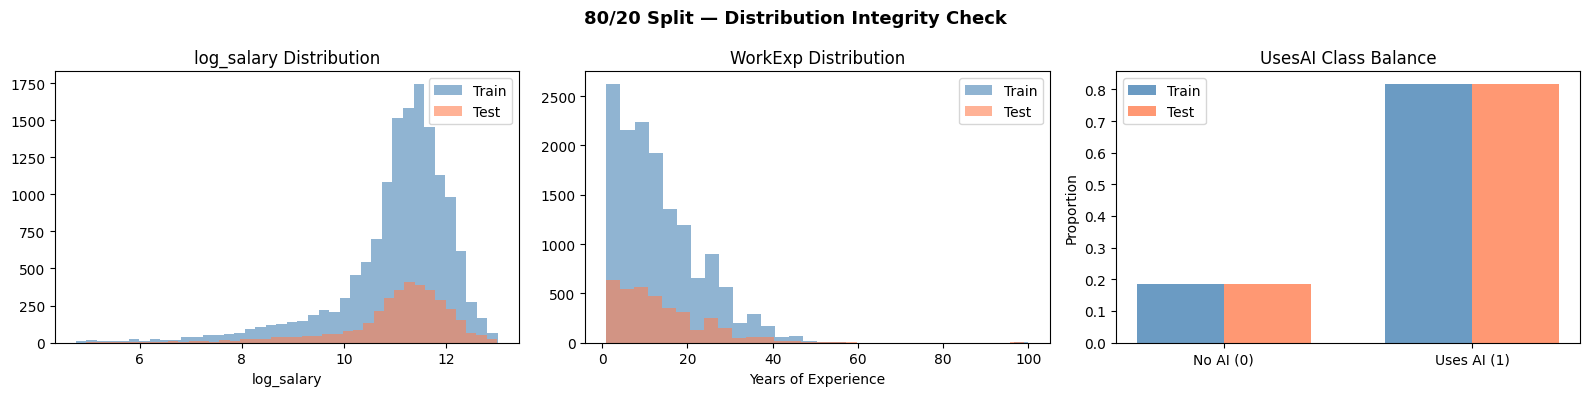

Distribution check saved.


In [12]:
# ── Visualise split distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('80/20 Split — Distribution Integrity Check', fontsize=13, fontweight='bold')

# log_salary
axes[0].hist(y_reg_train, bins=40, alpha=0.6, label='Train', color='steelblue')
axes[0].hist(y_reg_test,  bins=40, alpha=0.6, label='Test',  color='coral')
axes[0].set_title('log_salary Distribution')
axes[0].set_xlabel('log_salary')
axes[0].legend()

# WorkExp
axes[1].hist(X_reg_train['WorkExp'], bins=30, alpha=0.6, label='Train', color='steelblue')
axes[1].hist(X_reg_test['WorkExp'],  bins=30, alpha=0.6, label='Test',  color='coral')
axes[1].set_title('WorkExp Distribution')
axes[1].set_xlabel('Years of Experience')
axes[1].legend()

# UsesAI class balance
labels = ['No AI (0)', 'Uses AI (1)']
train_counts = y_clf_train.value_counts().sort_index()
test_counts  = y_clf_test.value_counts().sort_index()
x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, train_counts / len(y_clf_train), width, label='Train', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, test_counts  / len(y_clf_test),  width, label='Test',  color='coral',    alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_title('UsesAI Class Balance')
axes[2].set_ylabel('Proportion')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'split_integrity_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Distribution check saved.')

## SAVE SPLIT ARTEFACTS

All six arrays are saved to parquet. Notebooks 2 and 3 load from these files — they never re-split or access `df_model_cleaned` directly. This guarantees identical train/test rows across all pipelines.

In [13]:
# ── Save all split artefacts ──────────────────────────────────────────────
save_map = {
    'X_reg_train'  : X_reg_train,
    'X_reg_test'   : X_reg_test,
    'X_clf_train'  : X_clf_train,
    'X_clf_test'   : X_clf_test,
    'y_reg_train'  : y_reg_train.to_frame(),
    'y_reg_test'   : y_reg_test.to_frame(),
    'y_clf_train'  : y_clf_train.to_frame(),
    'y_clf_test'   : y_clf_test.to_frame(),
}

for name, data in save_map.items():
    path = os.path.join(config.OUTPUT_DIR, f'{name}.parquet')
    data.to_parquet(path, index=True)
    print(f'  Saved {name:<20} → {path}  shape={data.shape}')

print('\nAll artefacts saved. Notebooks 2 and 3 are ready to run.')
print('TEST SET IS NOW LOCKED — do not open X_reg_test or X_clf_test until final evaluation.')

  Saved X_reg_train          → ./data/X_reg_train.parquet  shape=(14411, 103)
  Saved X_reg_test           → ./data/X_reg_test.parquet  shape=(3603, 103)
  Saved X_clf_train          → ./data/X_clf_train.parquet  shape=(14411, 102)
  Saved X_clf_test           → ./data/X_clf_test.parquet  shape=(3603, 102)
  Saved y_reg_train          → ./data/y_reg_train.parquet  shape=(14411, 1)
  Saved y_reg_test           → ./data/y_reg_test.parquet  shape=(3603, 1)
  Saved y_clf_train          → ./data/y_clf_train.parquet  shape=(14411, 1)
  Saved y_clf_test           → ./data/y_clf_test.parquet  shape=(3603, 1)

All artefacts saved. Notebooks 2 and 3 are ready to run.
TEST SET IS NOW LOCKED — do not open X_reg_test or X_clf_test until final evaluation.


## FEATURE COLUMN MANIFEST

Saved for reference by downstream notebooks — confirms exact feature ordering.

In [14]:
import json

manifest = {
    'n_train'          : int(len(X_reg_train)),
    'n_test'           : int(len(X_reg_test)),
    'n_features_reg'   : int(X_reg_train.shape[1]),
    'n_features_clf'   : int(X_clf_train.shape[1]),
    'target_reg'       : config.TARGET_REG,
    'target_clf'       : config.TARGET_CLF,
    'clf_class_balance': float(y_clf_train.mean()),
    'continuous_cols'  : config.CONTINUOUS_COLS,
    'reg_feature_cols' : X_reg_train.columns.tolist(),
    'clf_feature_cols' : X_clf_train.columns.tolist(),
    'uses_ai_in_X_reg' : 'UsesAI' in X_reg_train.columns,
    'uses_ai_in_X_clf' : 'UsesAI' in X_clf_train.columns,
    'leakage_audit'    : 'PASS',
    'random_state'     : config.RANDOM_STATE,
    'test_size'        : config.TEST_SIZE
}

manifest_path = os.path.join(config.OUTPUT_DIR, 'pipeline_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print('Pipeline manifest saved:')
print(json.dumps({k: v for k, v in manifest.items() if k not in ['reg_feature_cols', 'clf_feature_cols']}, indent=2))
print(f'\nFull manifest at: {manifest_path}')

Pipeline manifest saved:
{
  "n_train": 14411,
  "n_test": 3603,
  "n_features_reg": 103,
  "n_features_clf": 102,
  "target_reg": "log_salary",
  "target_clf": "UsesAI",
  "clf_class_balance": 0.816320866005135,
  "continuous_cols": [
    "WorkExp"
  ],
  "uses_ai_in_X_reg": true,
  "uses_ai_in_X_clf": false,
  "leakage_audit": "PASS",
  "random_state": 42,
  "test_size": 0.2
}

Full manifest at: ./data/pipeline_manifest.json
